# Hartmann 6D brute force min_samples_leaf policies

This notebook analyzes all blockwise `min_samples_leaf` policies of length 5, where each block lasts 100 SMAC trials.

Candidate values are `[1, 2, 3, 5]`, so there are `4^4 = 256` policies per seed.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [2]:
ROOT = Path("/home/io632776/experiments/adaptive-smac/experiments/hartmann/06_brute_force_leaf_size")
RESULT_DIRECTORY = ROOT / "hartmann_6d_bruteforce_leaf_policies_400_trials_leaf_1_2_3_5"
FIGURE_DIRECTORY = ROOT / "figures"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

LEAF_VALUES = [1, 2, 3, 5]
SEEDS = range(5)
N_TRIALS = 400
MILESTONES = [100, 200, 300, 400]

print("result directory:", RESULT_DIRECTORY)

result directory: /home/io632776/experiments/adaptive-smac/experiments/hartmann/06_brute_force_leaf_size/hartmann_6d_bruteforce_leaf_policies_400_trials_leaf_1_2_3_5


## Load compact policy summaries

In [3]:
def load_policy_summaries() -> pd.DataFrame:
    rows = []
    for summary_path in RESULT_DIRECTORY.glob("leaf_policy_*/*/policy_summary.json"):
        with open(summary_path) as fh:
            summary = json.load(fh)

        policy = tuple(int(value) for value in summary["policy"])
        row = {
            "seed": int(summary["seed"]),
            "policy": policy,
            "policy_str": "-".join(str(value) for value in policy),
            "policy_name": summary["policy_name"],
            "final_incumbent_cost": float(summary["final_incumbent_cost"]),
            "run_dir": summary["run_dir"],
        }
        for milestone in MILESTONES:
            row[f"best_at_{milestone}"] = float(summary["milestone_best_costs"].get(str(milestone), np.nan))

        rows.append(row)

    return pd.DataFrame(rows).sort_values(["seed", "final_incumbent_cost"]).reset_index(drop=True)


df = load_policy_summaries()
print(f"loaded {len(df)} completed policy-seed runs")
df.head()

loaded 1280 completed policy-seed runs


,seed,policy,policy_str,policy_name,final_incumbent_cost,run_dir,best_at_100,best_at_200,best_at_300,best_at_400
0,0,"(3, 2, 3, 2)",3-2-3-2,leaf_policy_3_2_3_2,-3.201807,/home/io632776/experiments/adaptive-smac/exper...,-2.839603,-2.882357,-3.175540,-3.201807
1,0,"(5, 1, 3, 3)",5-1-3-3,leaf_policy_5_1_3_3,-3.201342,/home/io632776/experiments/adaptive-smac/exper...,-2.987219,-3.193605,-3.196949,-3.201342
2,0,"(5, 1, 2, 1)",5-1-2-1,leaf_policy_5_1_2_1,-3.201072,/home/io632776/experiments/adaptive-smac/exper...,-2.987219,-3.193605,-3.196974,-3.201072
3,0,"(5, 1, 3, 1)",5-1-3-1,leaf_policy_5_1_3_1,-3.200579,/home/io632776/experiments/adaptive-smac/exper...,-2.987219,-3.193605,-3.196949,-3.200579
4,0,"(3, 2, 2, 5)",3-2-2-5,leaf_policy_3_2_2_5,-3.200560,/home/io632776/experiments/adaptive-smac/exper...,-2.839603,-2.882357,-3.177425,-3.200560


## Completion overview

expected policies per seed: 256
expected total runs: 1280
completed total runs: 1280


,completed_runs
seed,
0,256
1,256
2,256
3,256
4,256


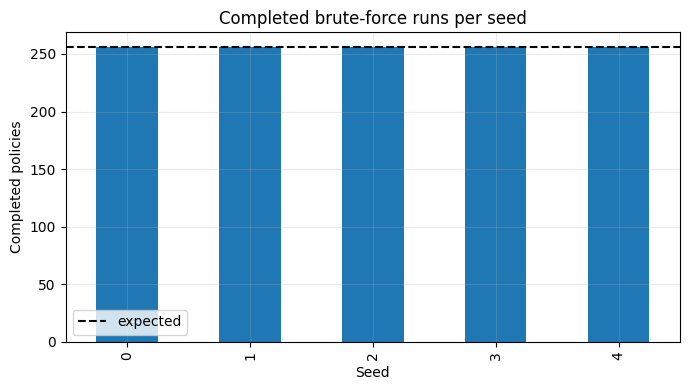

In [4]:
expected_policies = len(LEAF_VALUES) ** 4
expected_runs = expected_policies * len(list(SEEDS))
completed_by_seed = df.groupby("seed").size().reindex(list(SEEDS), fill_value=0)

print("expected policies per seed:", expected_policies)
print("expected total runs:", expected_runs)
print("completed total runs:", len(df))
display(completed_by_seed.to_frame("completed_runs"))

plt.figure(figsize=(7, 4))
completed_by_seed.plot(kind="bar")
plt.axhline(expected_policies, color="black", linestyle="--", linewidth=1.5, label="expected")
plt.title("Completed brute-force runs per seed")
plt.xlabel("Seed")
plt.ylabel("Completed policies")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "completed_runs_per_seed.png", dpi=200)
plt.show()

## Five best policies per seed

Lower cost is better.

In [5]:
top5_per_seed = (
    df.sort_values(["seed", "final_incumbent_cost"])
    .groupby("seed", group_keys=False)
    .head(5)
    .copy()
)
top5_per_seed["rank_in_seed"] = top5_per_seed.groupby("seed")["final_incumbent_cost"].rank(method="first")

display(
    top5_per_seed[
        ["seed", "rank_in_seed", "policy_str", "final_incumbent_cost", "best_at_100", "best_at_200", "best_at_300", "best_at_400"]
    ].sort_values(["seed", "rank_in_seed"])
)

,seed,rank_in_seed,policy_str,final_incumbent_cost,best_at_100,best_at_200,best_at_300,best_at_400
0,0,1.0,3-2-3-2,-3.201807,-2.839603,-2.882357,-3.175540,-3.201807
1,0,2.0,5-1-3-3,-3.201342,-2.987219,-3.193605,-3.196949,-3.201342
2,0,3.0,5-1-2-1,-3.201072,-2.987219,-3.193605,-3.196974,-3.201072
3,0,4.0,5-1-3-1,-3.200579,-2.987219,-3.193605,-3.196949,-3.200579
4,0,5.0,3-2-2-5,-3.200560,-2.839603,-2.882357,-3.177425,-3.200560
256,1,1.0,3-1-3-3,-3.318558,-2.545642,-3.059541,-3.293384,-3.318558
257,1,2.0,3-1-2-3,-3.317555,-2.545642,-3.059541,-3.314821,-3.317555
258,1,3.0,3-1-2-2,-3.316916,-2.545642,-3.059541,-3.314821,-3.316916
259,1,4.0,3-1-2-1,-3.316776,-2.545642,-3.059541,-3.314821,-3.316776
260,1,5.0,3-1-3-5,-3.316235,-2.545642,-3.059541,-3.293384,-3.316235


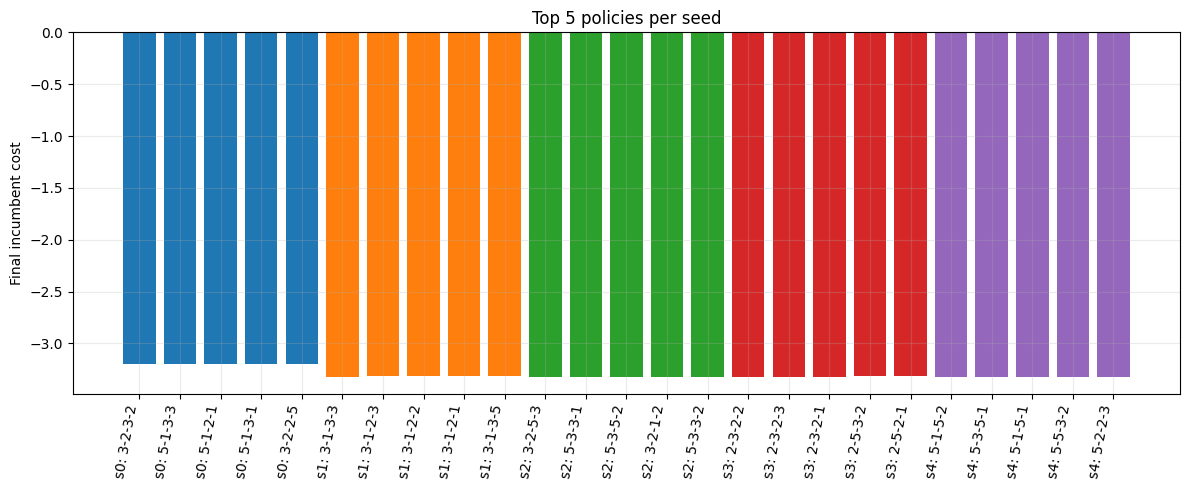

In [6]:
plt.figure(figsize=(12, 5))
for seed, seed_df in top5_per_seed.groupby("seed"):
    seed_df = seed_df.sort_values("rank_in_seed")
    labels = [f"s{seed}: {policy}" for policy in seed_df["policy_str"]]
    plt.bar(labels, seed_df["final_incumbent_cost"])

plt.title("Top 5 policies per seed")
plt.ylabel("Final incumbent cost")
plt.xticks(rotation=80, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "top5_policies_per_seed.png", dpi=200)
plt.show()

## Frequency of chosen leaf values among top 5, 10, 20, and 50 policies per seed

This pools the top N policies from each seed, then counts how often each `min_samples_leaf` value appears in block 1, block 2, block 3, and block 4.

In [7]:
def top_n_per_seed(data: pd.DataFrame, n: int) -> pd.DataFrame:
    return (
        data.sort_values(["seed", "final_incumbent_cost"])
        .groupby("seed", group_keys=False)
        .head(n)
        .copy()
    )


def block_leaf_frequency(top_df: pd.DataFrame) -> pd.DataFrame:
    policy_matrix = np.asarray([list(policy) for policy in top_df["policy"]], dtype=int)
    rows = []
    for block_idx in range(policy_matrix.shape[1]):
        values, counts = np.unique(policy_matrix[:, block_idx], return_counts=True)
        count_map = dict(zip(values, counts))
        for leaf in LEAF_VALUES:
            rows.append(
                {
                    "block": block_idx + 1,
                    "min_samples_leaf": leaf,
                    "count": int(count_map.get(leaf, 0)),
                }
            )

    return pd.DataFrame(rows)


frequency_tables = {}
for top_n in [5, 10, 20, 50]:
    top_df = top_n_per_seed(df, top_n)
    frequency_df = block_leaf_frequency(top_df)
    frequency_tables[top_n] = frequency_df

    print(f"Top {top_n} policies per seed: {len(top_df)} pooled policies")
    display(frequency_df.pivot(index="min_samples_leaf", columns="block", values="count"))

Top 5 policies per seed: 25 pooled policies


block,1,2,3,4
min_samples_leaf,,,,
1,0,10,1,8
2,5,5,10,9
3,9,7,9,6
5,11,3,5,2


Top 10 policies per seed: 50 pooled policies


block,1,2,3,4
min_samples_leaf,,,,
1,0,16,5,13
2,11,10,17,12
3,17,12,15,14
5,22,12,13,11


Top 20 policies per seed: 100 pooled policies


block,1,2,3,4
min_samples_leaf,,,,
1,0,32,23,29
2,21,25,26,27
3,37,20,28,23
5,42,23,23,21


Top 50 policies per seed: 250 pooled policies


block,1,2,3,4
min_samples_leaf,,,,
1,0,79,71,64
2,73,59,63,68
3,82,42,61,63
5,95,70,55,55


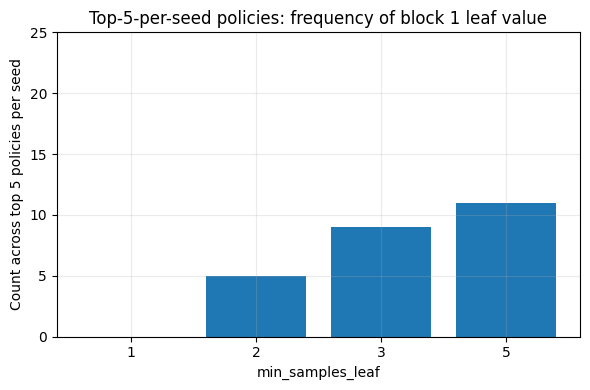

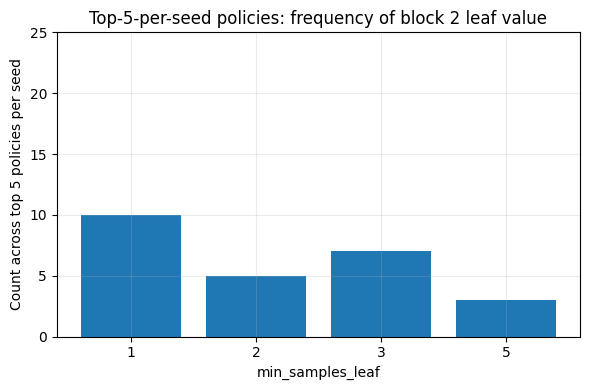

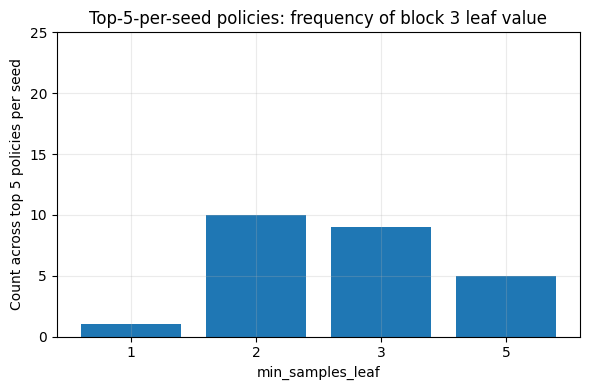

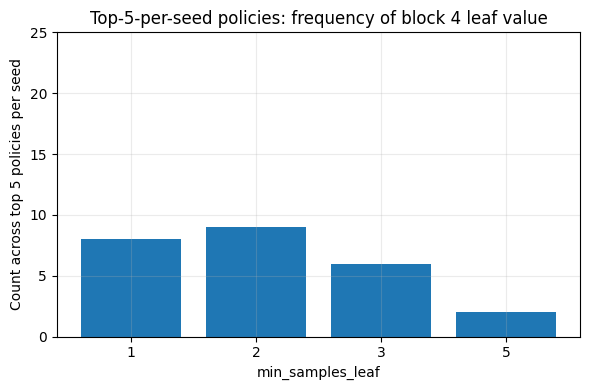

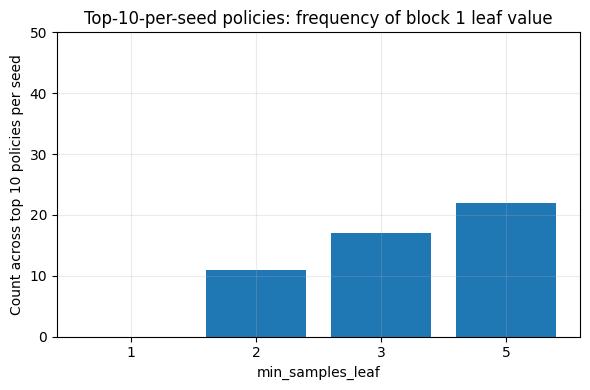

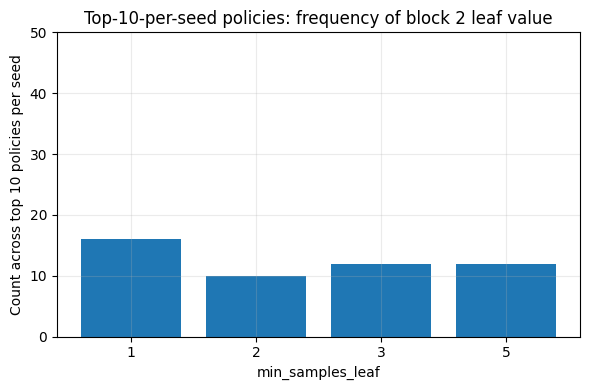

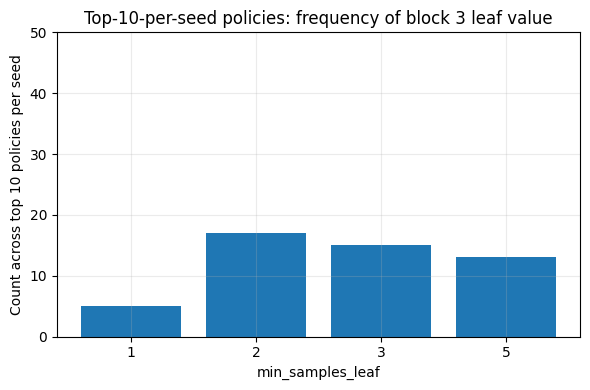

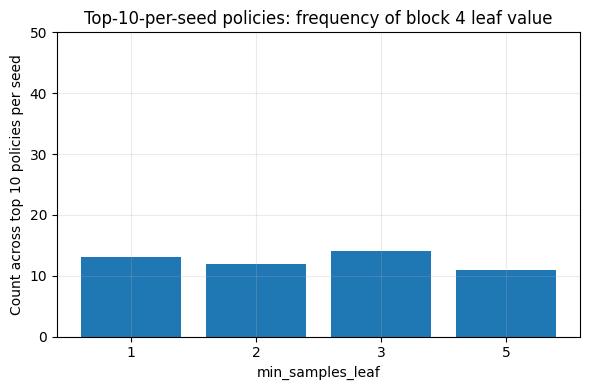

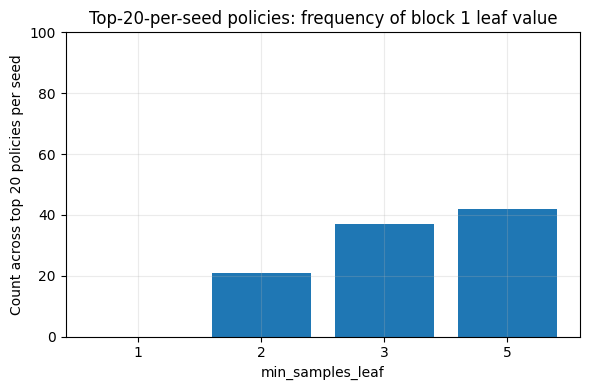

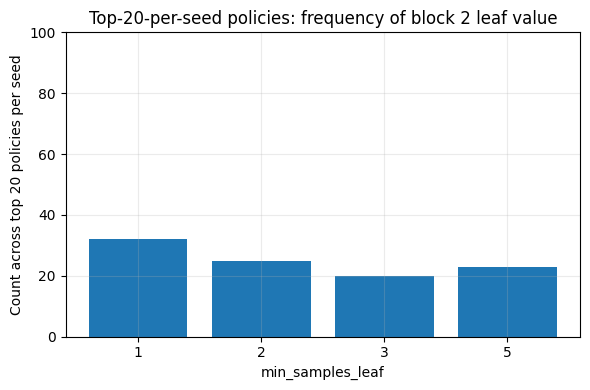

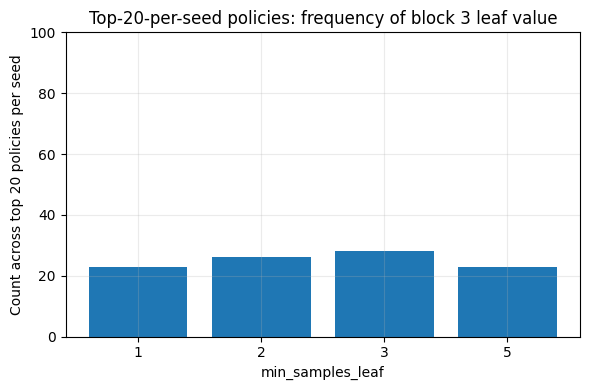

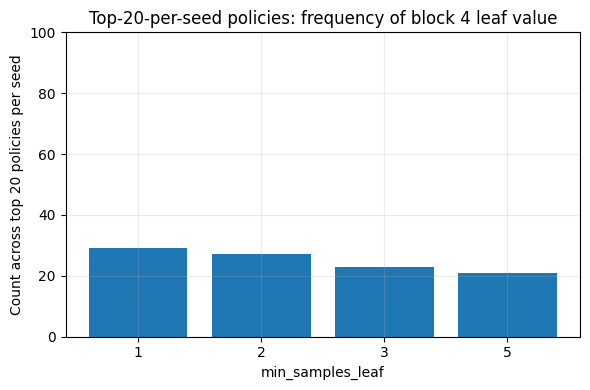

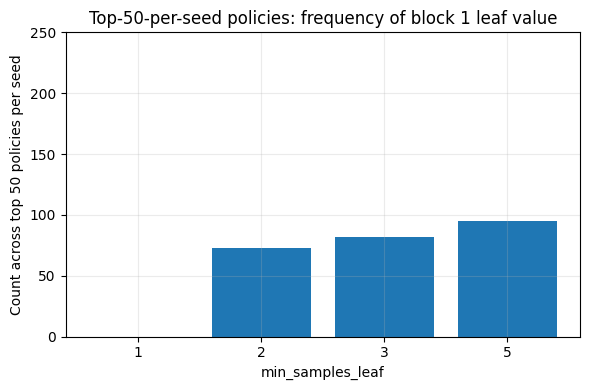

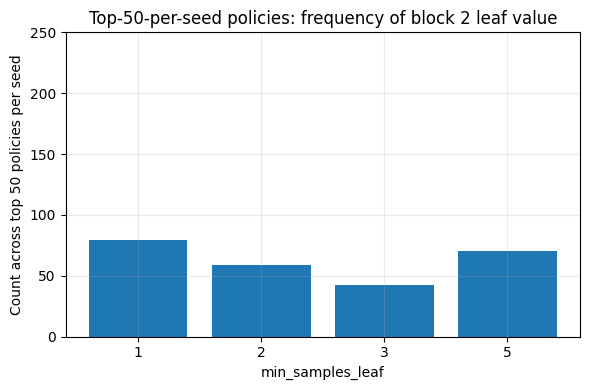

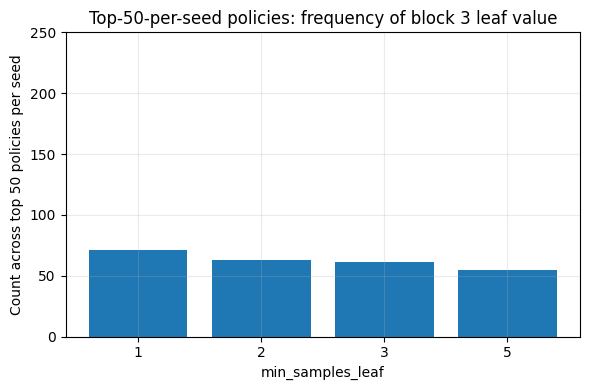

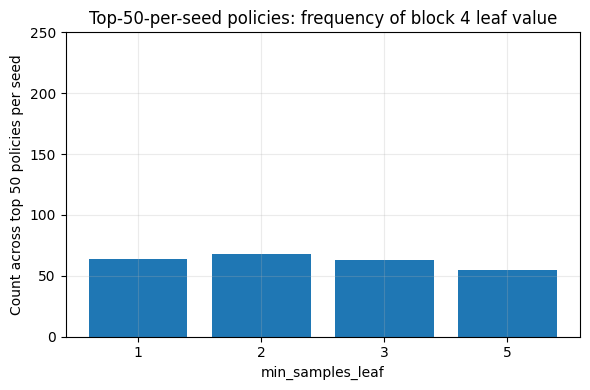

In [8]:
for top_n, frequency_df in frequency_tables.items():
    max_count = top_n * df["seed"].nunique()
    for block in range(1, 5):
        block_df = frequency_df[frequency_df["block"] == block]

        plt.figure(figsize=(6, 4))
        plt.bar(block_df["min_samples_leaf"].astype(str), block_df["count"])
        plt.title(f"Top-{top_n}-per-seed policies: frequency of block {block} leaf value")
        plt.xlabel("min_samples_leaf")
        plt.ylabel(f"Count across top {top_n} policies per seed")
        plt.ylim(0, max_count)
        plt.tight_layout()
        plt.savefig(FIGURE_DIRECTORY / f"top{top_n}_per_seed_block_{block}_leaf_frequency.png", dpi=200)
        plt.show()

## Best five policies overall

Overall ranking uses the mean final incumbent cost across seeds. By default, only policies with all 5 seeds completed are included.

In [9]:
overall = (
    df.groupby(["policy", "policy_str"])
    .agg(
        mean_final_cost=("final_incumbent_cost", "mean"),
        std_final_cost=("final_incumbent_cost", "std"),
        min_final_cost=("final_incumbent_cost", "min"),
        max_final_cost=("final_incumbent_cost", "max"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)

complete_overall = overall[overall["n_seeds"] == len(list(SEEDS))].sort_values("mean_final_cost").reset_index(drop=True)
top5_overall = complete_overall.head(5).copy()
top5_overall["overall_rank"] = np.arange(1, len(top5_overall) + 1)

display(top5_overall[["overall_rank", "policy_str", "mean_final_cost", "std_final_cost", "min_final_cost", "max_final_cost", "n_seeds"]])

,overall_rank,policy_str,mean_final_cost,std_final_cost,min_final_cost,max_final_cost,n_seeds
0,1,3-1-3-3,-3.263007,0.076111,-3.319747,-3.170219,5
1,2,3-1-1-3,-3.255717,0.057880,-3.316199,-3.192999,5
2,3,5-3-1-2,-3.247523,0.065987,-3.320137,-3.193599,5
3,4,5-3-1-1,-3.247008,0.065091,-3.318685,-3.195809,5
4,5,5-3-5-3,-3.245193,0.069355,-3.321389,-3.183658,5


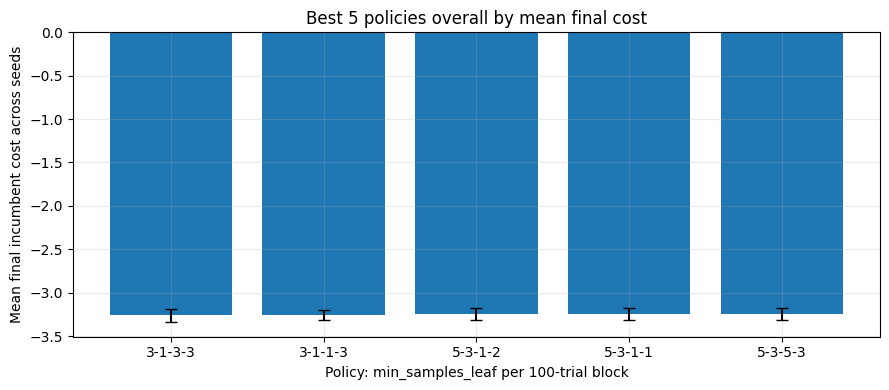

In [10]:
plt.figure(figsize=(9, 4))
plt.bar(top5_overall["policy_str"], top5_overall["mean_final_cost"], yerr=top5_overall["std_final_cost"], capsize=4)
plt.title("Best 5 policies overall by mean final cost")
plt.xlabel("Policy: min_samples_leaf per 100-trial block")
plt.ylabel("Mean final incumbent cost across seeds")
plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "top5_policies_overall_mean_final_cost.png", dpi=200)
plt.show()

## Final cost boxplots for the overall top policies

/tmp/io632776/login23-4_127934/ipykernel_259182/2249972539.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=top_policy_strings, showmeans=True)


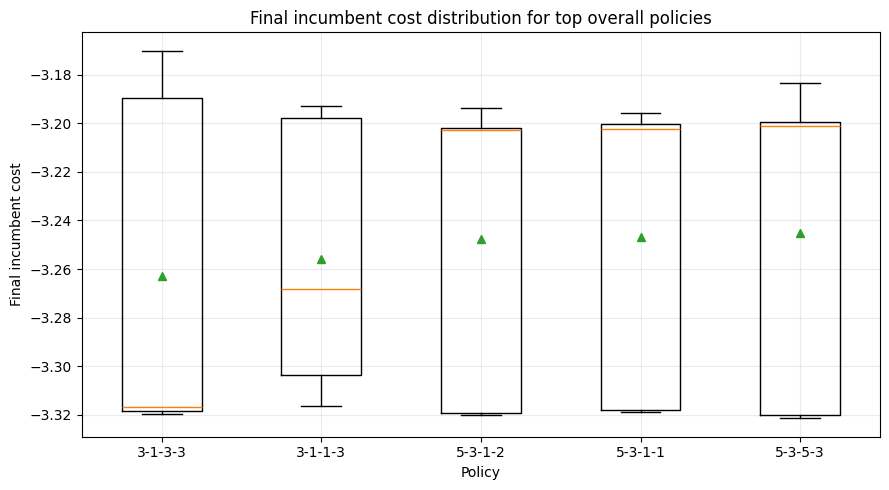

In [11]:
top_policy_strings = top5_overall["policy_str"].tolist()
boxplot_data = [df.loc[df["policy_str"] == policy, "final_incumbent_cost"].to_numpy() for policy in top_policy_strings]

plt.figure(figsize=(9, 5))
plt.boxplot(boxplot_data, labels=top_policy_strings, showmeans=True)
plt.title("Final incumbent cost distribution for top overall policies")
plt.xlabel("Policy")
plt.ylabel("Final incumbent cost")
plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "top5_overall_final_cost_boxplots.png", dpi=200)
plt.show()

## Trajectory plot for top overall policies

This loads full `runhistory.json` files only for the top 5 overall policies.

In [12]:
def runhistory_costs_in_order(run_dir: Path) -> np.ndarray:
    with open(run_dir / "runhistory.json") as fh:
        runhistory = json.load(fh)

    rows = sorted(runhistory["data"], key=lambda row: (row["starttime"], row["endtime"]))
    return np.asarray([float(row["cost"]) for row in rows], dtype=float)


def best_so_far(costs: Iterable[float]) -> np.ndarray:
    return np.minimum.accumulate(np.asarray(list(costs), dtype=float))


def mean_ci(values: np.ndarray, confidence: float = 0.95) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    mean = np.nanmean(values, axis=0)
    n = np.sum(~np.isnan(values), axis=0)
    std = np.nanstd(values, axis=0, ddof=1)
    stderr = std / np.sqrt(n)
    critical = t.ppf((1 + confidence) / 2, n - 1)
    half_width = np.where(n > 1, critical * stderr, 0.0)
    return mean, mean - half_width, mean + half_width


def trajectories_for_policy(policy_str: str) -> list[np.ndarray]:
    runs = []
    for run_dir in df.loc[df["policy_str"] == policy_str, "run_dir"]:
        trajectory = best_so_far(runhistory_costs_in_order(Path(run_dir)))
        if len(trajectory) >= N_TRIALS:
            runs.append(trajectory[:N_TRIALS])
    return runs

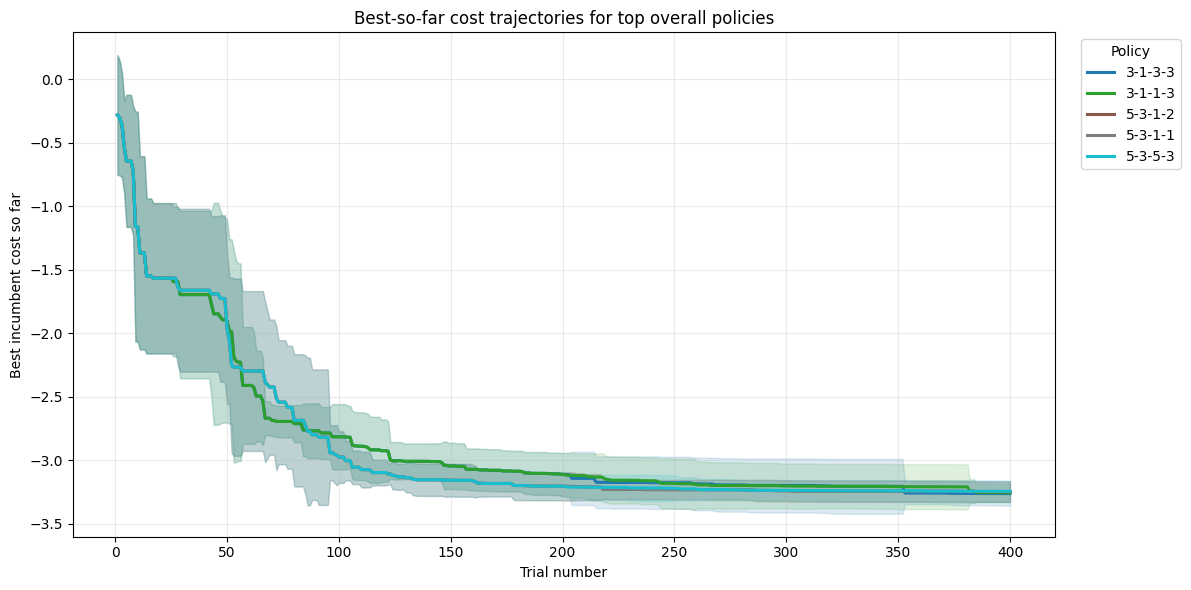

In [13]:
xs = np.arange(1, N_TRIALS + 1)
colors = plt.cm.tab10(np.linspace(0, 1, len(top_policy_strings)))

plt.figure(figsize=(12, 6))
for policy_str, color in zip(top_policy_strings, colors):
    runs = trajectories_for_policy(policy_str)
    if not runs:
        continue
    values = np.vstack(runs)
    mean, lower, upper = mean_ci(values)
    plt.plot(xs, mean, label=policy_str, color=color, linewidth=2.2)
    plt.fill_between(xs, lower, upper, color=color, alpha=0.15)

plt.title("Best-so-far cost trajectories for top overall policies")
plt.xlabel("Trial number")
plt.ylabel("Best incumbent cost so far")
plt.legend(title="Policy", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "top5_overall_trajectories_with_ci.png", dpi=200)
plt.show()

## Best leaf value per block among top policies

A compact view of which `min_samples_leaf` values appear in the best policies.

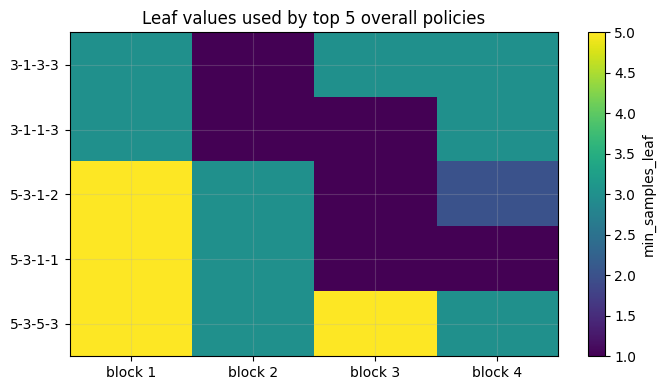

In [14]:
if len(top5_overall):
    policy_matrix = np.asarray([list(policy) for policy in top5_overall["policy"]], dtype=int)
    plt.figure(figsize=(7, 4))
    im = plt.imshow(policy_matrix, aspect="auto", cmap="viridis", vmin=min(LEAF_VALUES), vmax=max(LEAF_VALUES))
    plt.colorbar(im, label="min_samples_leaf")
    plt.yticks(np.arange(len(top5_overall)), top5_overall["policy_str"])
    plt.xticks(np.arange(4), [f"block {i}" for i in range(1, 5)])
    plt.title("Leaf values used by top 5 overall policies")
    plt.tight_layout()
    plt.savefig(FIGURE_DIRECTORY / "top5_overall_policy_heatmap.png", dpi=200)
    plt.show()

## Per-seed comparison: best 2 dynamic policies vs fixed leaf baselines

For each seed, compare that seed's best two brute-force dynamic policies against fixed `min_samples_leaf` values `1, 2, 3, 5`.

In [15]:
FIXED_BASELINE_DIRECTORY = ROOT / "hartmann_6d_fixed_leaf_baselines_400_trials_leaf_1_2_3_5"


def load_fixed_baseline_summaries() -> pd.DataFrame:
    rows = []
    for summary_path in FIXED_BASELINE_DIRECTORY.glob("fixed_leaf_*/*/policy_summary.json"):
        with open(summary_path) as fh:
            summary = json.load(fh)

        leaf = int(summary["min_samples_leaf"])
        row = {
            "seed": int(summary["seed"]),
            "leaf": leaf,
            "label": f"fixed leaf {leaf}",
            "final_incumbent_cost": float(summary["final_incumbent_cost"]),
            "run_dir": summary["run_dir"],
        }
        for milestone in MILESTONES:
            row[f"best_at_{milestone}"] = float(summary["milestone_best_costs"].get(str(milestone), np.nan))
        rows.append(row)

    return pd.DataFrame(rows).sort_values(["seed", "leaf"]).reset_index(drop=True)


fixed_df = load_fixed_baseline_summaries()
print(f"loaded {len(fixed_df)} fixed-baseline runs")
fixed_df

loaded 20 fixed-baseline runs


,seed,leaf,label,final_incumbent_cost,run_dir,best_at_100,best_at_200,best_at_300,best_at_400
0,0,1,fixed leaf 1,-3.182721,/home/io632776/experiments/adaptive-smac/exper...,-2.988438,-3.104304,-3.157417,-3.182721
1,0,2,fixed leaf 2,-3.186764,/home/io632776/experiments/adaptive-smac/exper...,-2.849930,-2.906540,-3.106558,-3.186764
2,0,3,fixed leaf 3,-2.885144,/home/io632776/experiments/adaptive-smac/exper...,-2.839603,-2.882620,-2.883473,-2.885144
3,0,5,fixed leaf 5,-3.200413,/home/io632776/experiments/adaptive-smac/exper...,-2.987219,-3.186663,-3.199514,-3.200413
4,1,1,fixed leaf 1,-3.143340,/home/io632776/experiments/adaptive-smac/exper...,-2.955863,-3.140404,-3.143141,-3.143340
5,1,2,fixed leaf 2,-3.198639,/home/io632776/experiments/adaptive-smac/exper...,-3.116169,-3.196047,-3.198075,-3.198639
6,1,3,fixed leaf 3,-3.311522,/home/io632776/experiments/adaptive-smac/exper...,-2.545642,-3.069279,-3.171007,-3.311522
7,1,5,fixed leaf 5,-3.195058,/home/io632776/experiments/adaptive-smac/exper...,-2.762436,-3.090983,-3.193046,-3.195058
8,2,1,fixed leaf 1,-3.301983,/home/io632776/experiments/adaptive-smac/exper...,-3.151948,-3.267334,-3.301254,-3.301983
9,2,2,fixed leaf 2,-3.107730,/home/io632776/experiments/adaptive-smac/exper...,-2.407450,-3.016178,-3.057396,-3.107730


In [16]:
best2_dynamic_per_seed = (
    df.sort_values(["seed", "final_incumbent_cost"])
    .groupby("seed", group_keys=False)
    .head(2)
    .copy()
)
best2_dynamic_per_seed["label"] = "dynamic " + best2_dynamic_per_seed["policy_str"]

comparison_rows = []
for _, row in best2_dynamic_per_seed.iterrows():
    comparison_rows.append(
        {
            "seed": row["seed"],
            "kind": "dynamic best2",
            "label": row["label"],
            "final_incumbent_cost": row["final_incumbent_cost"],
            "run_dir": row["run_dir"],
        }
    )

for _, row in fixed_df.iterrows():
    comparison_rows.append(
        {
            "seed": row["seed"],
            "kind": "fixed baseline",
            "label": row["label"],
            "final_incumbent_cost": row["final_incumbent_cost"],
            "run_dir": row["run_dir"],
        }
    )

seed_comparison_df = pd.DataFrame(comparison_rows)
display(seed_comparison_df.sort_values(["seed", "final_incumbent_cost"]))

,seed,kind,label,final_incumbent_cost,run_dir
0,0,dynamic best2,dynamic 3-2-3-2,-3.201807,/home/io632776/experiments/adaptive-smac/exper...
1,0,dynamic best2,dynamic 5-1-3-3,-3.201342,/home/io632776/experiments/adaptive-smac/exper...
13,0,fixed baseline,fixed leaf 5,-3.200413,/home/io632776/experiments/adaptive-smac/exper...
11,0,fixed baseline,fixed leaf 2,-3.186764,/home/io632776/experiments/adaptive-smac/exper...
10,0,fixed baseline,fixed leaf 1,-3.182721,/home/io632776/experiments/adaptive-smac/exper...
12,0,fixed baseline,fixed leaf 3,-2.885144,/home/io632776/experiments/adaptive-smac/exper...
2,1,dynamic best2,dynamic 3-1-3-3,-3.318558,/home/io632776/experiments/adaptive-smac/exper...
3,1,dynamic best2,dynamic 3-1-2-3,-3.317555,/home/io632776/experiments/adaptive-smac/exper...
16,1,fixed baseline,fixed leaf 3,-3.311522,/home/io632776/experiments/adaptive-smac/exper...
15,1,fixed baseline,fixed leaf 2,-3.198639,/home/io632776/experiments/adaptive-smac/exper...


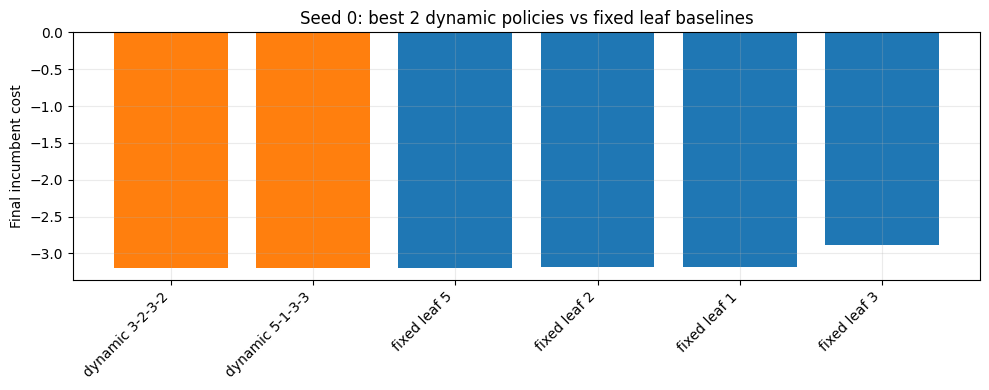

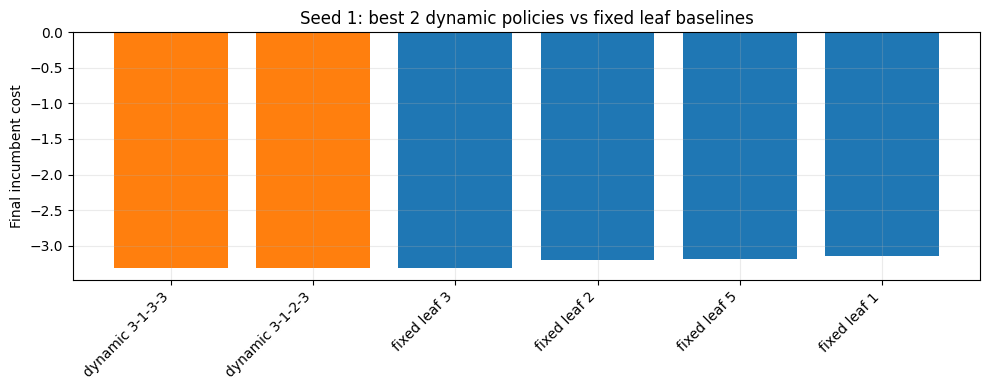

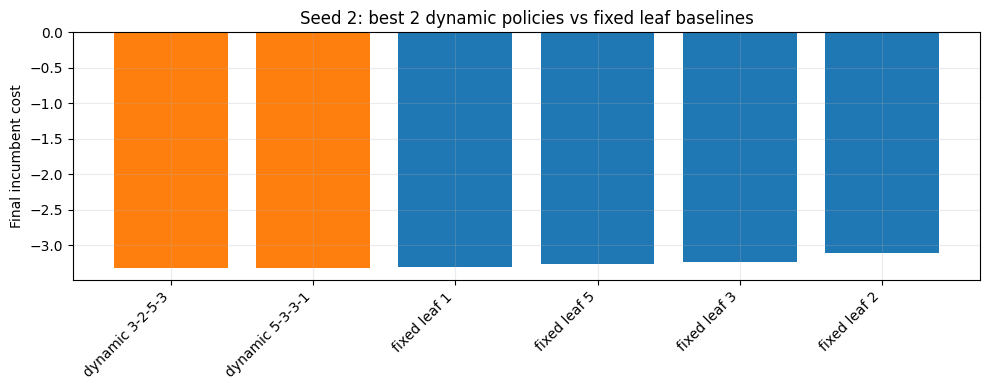

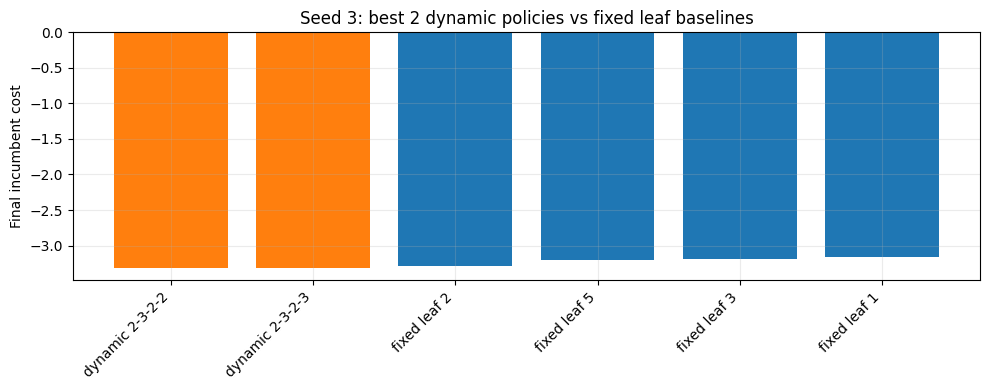

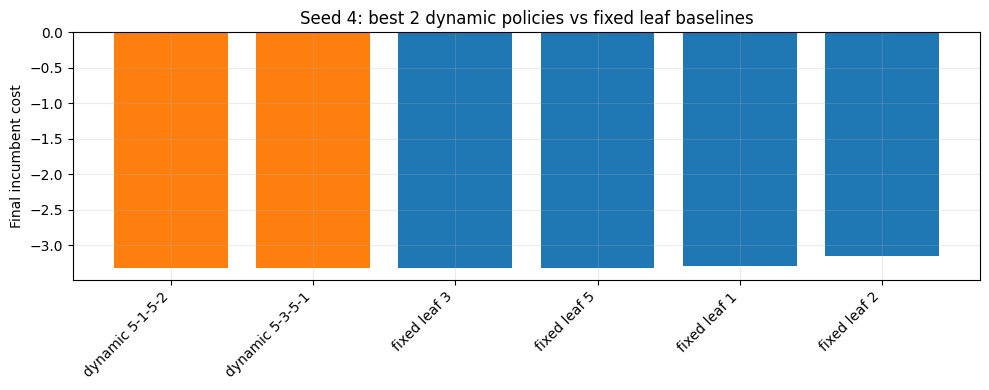

In [17]:
for seed in sorted(seed_comparison_df["seed"].unique()):
    seed_df = seed_comparison_df[seed_comparison_df["seed"] == seed].sort_values("final_incumbent_cost")
    colors = ["tab:orange" if kind == "dynamic best2" else "tab:blue" for kind in seed_df["kind"]]

    plt.figure(figsize=(10, 4))
    plt.bar(seed_df["label"], seed_df["final_incumbent_cost"], color=colors)
    plt.title(f"Seed {seed}: best 2 dynamic policies vs fixed leaf baselines")
    plt.ylabel("Final incumbent cost")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURE_DIRECTORY / f"seed_{seed}_best2_dynamic_vs_fixed_final_cost.png", dpi=200)
    plt.show()

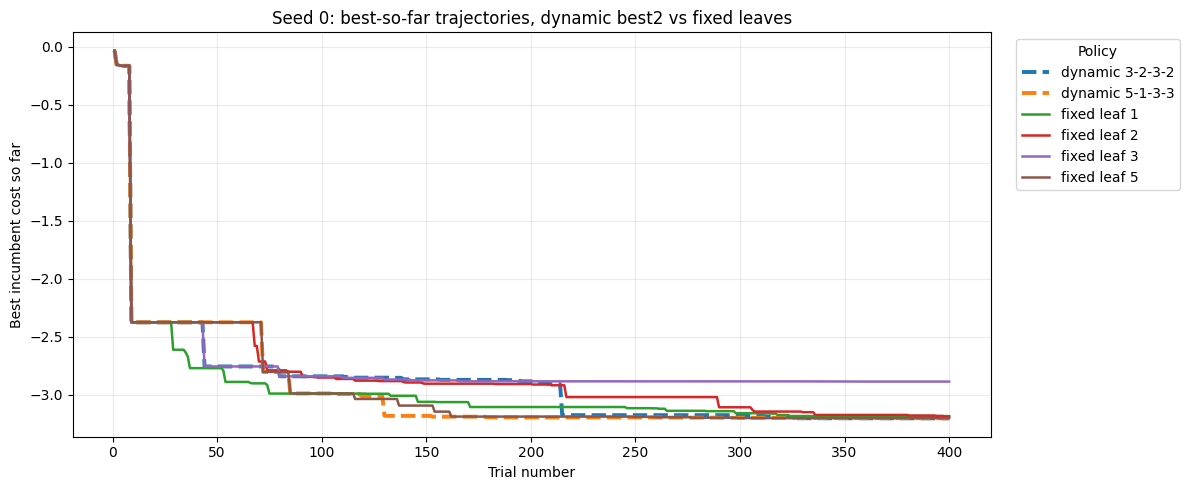

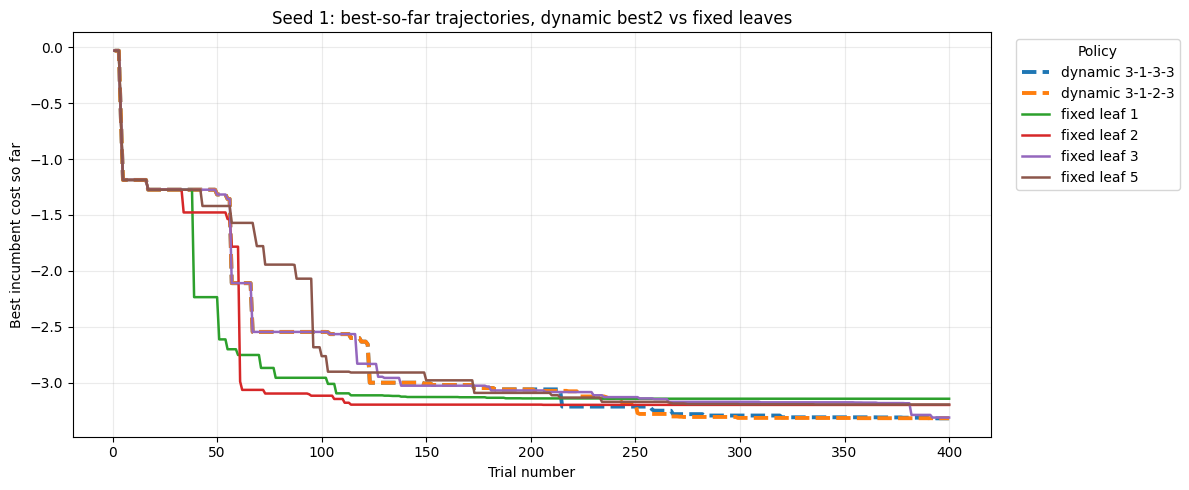

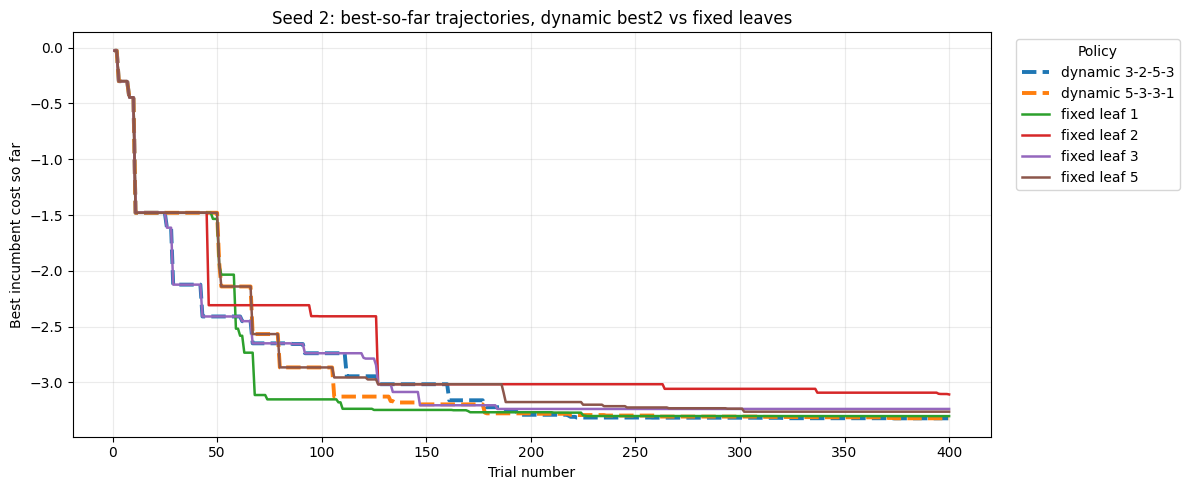

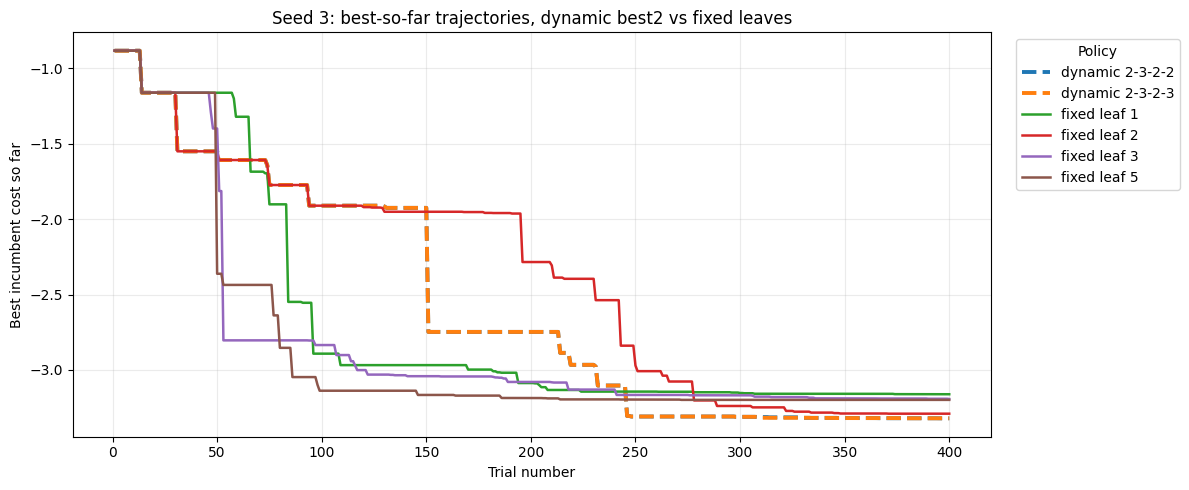

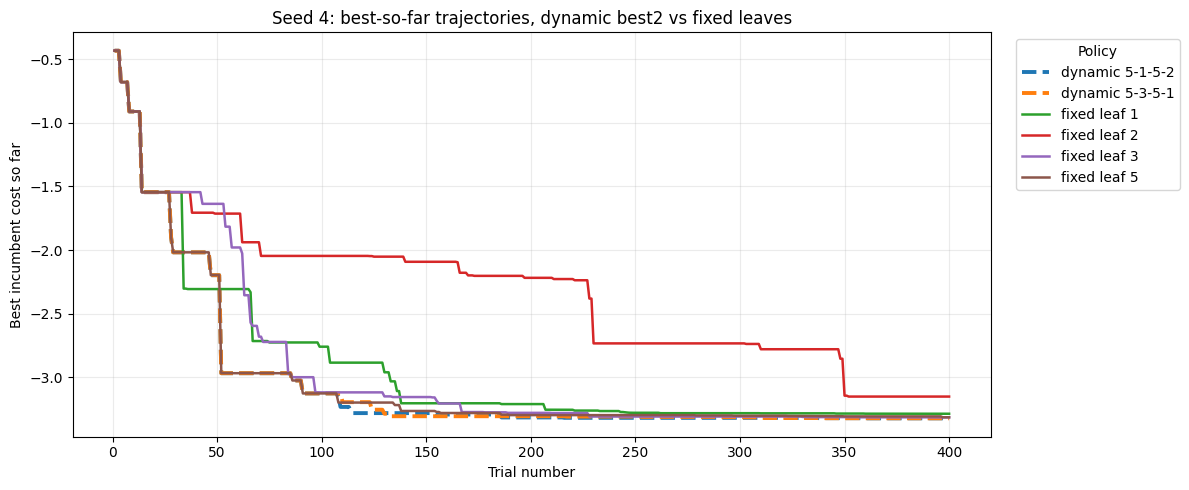

In [18]:
for seed in sorted(seed_comparison_df["seed"].unique()):
    seed_df = seed_comparison_df[seed_comparison_df["seed"] == seed].copy()
    plt.figure(figsize=(12, 5))

    for _, row in seed_df.iterrows():
        trajectory = best_so_far(runhistory_costs_in_order(Path(row["run_dir"])))[:N_TRIALS]
        linestyle = "--" if row["kind"] == "dynamic best2" else "-"
        linewidth = 2.8 if row["kind"] == "dynamic best2" else 1.8
        plt.plot(
            np.arange(1, len(trajectory) + 1),
            trajectory,
            label=row["label"],
            linestyle=linestyle,
            linewidth=linewidth,
        )

    plt.title(f"Seed {seed}: best-so-far trajectories, dynamic best2 vs fixed leaves")
    plt.xlabel("Trial number")
    plt.ylabel("Best incumbent cost so far")
    plt.legend(title="Policy", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURE_DIRECTORY / f"seed_{seed}_best2_dynamic_vs_fixed_trajectories.png", dpi=200)
    plt.show()

In [19]:
from __future__ import annotations

import json
import shutil
import tempfile
from pathlib import Path
from typing import Any, Iterable, Tuple

import numpy as np
import pandas as pd

from ConfigSpace import Configuration, ConfigurationSpace, Float
from smac import HyperparameterOptimizationFacade as HPOFacade
from smac import Scenario
from smac.callback import Callback

from master_utils.benchmarks import hartmann
from master_utils.reload_components import load_smac_components


SEED = 0
DYNAMIC_POLICY = (2, 3, 5, 1)
POLICY_LENGTH = 4
N_TRIALS = 400
TRIALS_PER_BLOCK = 100
N_INITIAL_DESIGN_CONFIGS = 25


def policy_name(policy: Tuple[int, ...]) -> str:
    return "leaf_policy_" + "_".join(str(value) for value in policy)


def ordered_costs_from_runhistory(runhistory) -> list[float]:
    ordered_trials = sorted(
        runhistory.items(),
        key=lambda item: (item[1].starttime, item[1].endtime),
    )
    return [float(value.cost) for _, value in ordered_trials]


def best_so_far(costs: Iterable[float]) -> list[float]:
    best = []
    current = float("inf")
    for cost in costs:
        current = min(current, cost)
        best.append(current)
    return best


REFERENCE_SEED = SEED
REFERENCE_POLICY = DYNAMIC_POLICY
REFERENCE_POLICY_NAME = policy_name(REFERENCE_POLICY)

reference_rows = df[(df["seed"] == REFERENCE_SEED) & (df["policy"] == REFERENCE_POLICY)]
if reference_rows.empty:
    raise ValueError(f"No saved run found for seed={REFERENCE_SEED}, policy={REFERENCE_POLICY!r}")

reference_row = reference_rows.sort_values("final_incumbent_cost").iloc[0]
REFERENCE_RUN_DIR = Path(reference_row["run_dir"])

print("reference run directory:", REFERENCE_RUN_DIR)
display(
    reference_row[
        [
            "seed",
            "policy_str",
            "final_incumbent_cost",
            "best_at_100",
            "best_at_200",
            "best_at_300",
            "best_at_400",
        ]
    ]
)

reference_components = load_smac_components(REFERENCE_RUN_DIR)
reference_runhistory = reference_components["runhistory"]
reference_costs = ordered_costs_from_runhistory(reference_runhistory)
reference_trajectory = best_so_far(reference_costs)

print("reference runhistory length:", len(reference_trajectory))
print("reference final best-so-far cost:", reference_trajectory[-1])


class BlockwiseMinSamplesLeafCallback(Callback):
    """Record when each leaf-size block becomes active during replay."""

    def __init__(self, policy: Tuple[int, ...]) -> None:
        super().__init__()
        if len(policy) != POLICY_LENGTH:
            raise ValueError(f"Expected policy length {POLICY_LENGTH}, got {policy!r}")
        self._policy = policy
        self._last_leaf = None
        self.history: list[dict[str, Any]] = []

    def on_next_configurations_start(self, config_selector) -> None:
        n_trials = len(config_selector._runhistory)
        block_idx = min(n_trials // TRIALS_PER_BLOCK, len(self._policy) - 1)
        min_samples_leaf = self._policy[block_idx]

        before = config_selector._model._rf_opts.get("min_samples_leaf")
        config_selector._model._rf_opts["min_samples_leaf"] = min_samples_leaf
        after = config_selector._model._rf_opts.get("min_samples_leaf")

        self.history.append(
            {
                "n_trials": n_trials,
                "block_idx": block_idx,
                "min_samples_leaf_before": before,
                "min_samples_leaf_after": after,
            }
        )

        if min_samples_leaf != self._last_leaf:
            print(
                f"[BlockwiseMinSamplesLeafCallback] trials={n_trials}, "
                f"block={block_idx + 1}, min_samples_leaf={min_samples_leaf}"
            )
            self._last_leaf = min_samples_leaf


def make_configspace(seed: int) -> ConfigurationSpace:
    configspace = ConfigurationSpace(seed=seed)
    configspace.add([Float(f"x{i}", (0.0, 1.0)) for i in range(1, 7)])
    return configspace


def hartmann_6d_eval(config: Configuration, seed: int = 0) -> float:
    return hartmann([config[f"x{i}"] for i in range(1, 7)], 6)


def run_replay(output_directory: Path, overwrite: bool) -> tuple[Any, BlockwiseMinSamplesLeafCallback]:
    configspace = make_configspace(REFERENCE_SEED)
    scenario = Scenario(
        name=REFERENCE_POLICY_NAME,
        output_directory=output_directory,
        configspace=configspace,
        deterministic=True,
        n_trials=N_TRIALS,
        seed=REFERENCE_SEED,
    )

    model = HPOFacade.get_model(
        scenario=scenario,
        min_samples_leaf=REFERENCE_POLICY[0],
    )
    initial_design = HPOFacade.get_initial_design(
        scenario=scenario,
        n_configs=N_INITIAL_DESIGN_CONFIGS,
    )
    callback = BlockwiseMinSamplesLeafCallback(REFERENCE_POLICY)

    print("\nRunning replay")
    print("output directory:", output_directory)
    print("overwrite:", overwrite)
    print("initial model min_samples_leaf:", model._rf_opts["min_samples_leaf"])

    smac = HPOFacade(
        scenario=scenario,
        target_function=hartmann_6d_eval,
        model=model,
        initial_design=initial_design,
        callbacks=[callback],
        overwrite=overwrite,
    )
    incumbent = smac.optimize()
    incumbent_cost = float(smac.runhistory.get_cost(incumbent))

    print("replay incumbent cost:", incumbent_cost)
    print("final model min_samples_leaf:", smac._model._rf_opts["min_samples_leaf"])
    return smac, callback


def first_difference(reference: Iterable[float], candidate: Iterable[float]) -> int | None:
    reference_array = np.asarray(list(reference), dtype=float)
    candidate_array = np.asarray(list(candidate), dtype=float)
    n = min(len(reference_array), len(candidate_array))
    mismatches = np.where(~np.isclose(reference_array[:n], candidate_array[:n], rtol=0.0, atol=1e-12))[0]
    if len(mismatches):
        return int(mismatches[0])
    if len(reference_array) != len(candidate_array):
        return n
    return None


sandbox_root = Path(tempfile.mkdtemp(prefix="smac_leaf_replay_"))
reference_copy_dir = sandbox_root / "reference_copy"
clean_replay_dir = sandbox_root / "clean_replay"

shutil.copytree(REFERENCE_RUN_DIR, reference_copy_dir)
clean_replay_dir.mkdir(parents=True, exist_ok=True)

print("sandbox root:", sandbox_root)
print("copied reference dir:", reference_copy_dir)
print("clean replay dir:", clean_replay_dir)

smac_copy, callback_copy = run_replay(reference_copy_dir, overwrite=False)
smac_clean, callback_clean = run_replay(clean_replay_dir, overwrite=True)

replays = [
    ("copied reference / overwrite=False", smac_copy, callback_copy),
    ("clean replay / overwrite=True", smac_clean, callback_clean),
]

for label, smac, callback in replays:
    candidate_trajectory = best_so_far(ordered_costs_from_runhistory(smac.runhistory))
    diff_idx = first_difference(reference_trajectory, candidate_trajectory)

    print(f"\n=== {label} ===")
    print("candidate runhistory length:", len(candidate_trajectory))
    print("candidate final best-so-far cost:", candidate_trajectory[-1])

    if diff_idx is None:
        print("trajectory matches the reference exactly")
    else:
        print(f"first difference at trial {diff_idx + 1}")
        print("reference:", reference_trajectory[diff_idx])
        print("candidate:", candidate_trajectory[diff_idx])

    callback_df = pd.DataFrame(callback.history)
    if not callback_df.empty:
        change_points = callback_df[callback_df["min_samples_leaf_before"] != callback_df["min_samples_leaf_after"]]
        print("leaf-change points:")
        display(change_points.reset_index(drop=True))
        print("callback tail:")
        display(callback_df.tail(10))
    else:
        print("callback did not record any transitions")


reference run directory: /home/io632776/experiments/adaptive-smac/experiments/hartmann/06_brute_force_leaf_size/hartmann_6d_bruteforce_leaf_policies_400_trials_leaf_1_2_3_5/leaf_policy_2_3_5_1/0


seed                           0
policy_str               2-3-5-1
final_incumbent_cost   -3.197991
best_at_100             -2.84993
best_at_200            -2.913424
best_at_300            -3.191482
best_at_400            -3.197991
Name: 53, dtype: object

reference runhistory length: 400
reference final best-so-far cost: -3.197991256318672
sandbox root: /tmp/io632776/login23-4_127934/smac_leaf_replay_lgqrmba4
copied reference dir: /tmp/io632776/login23-4_127934/smac_leaf_replay_lgqrmba4/reference_copy
clean replay dir: /tmp/io632776/login23-4_127934/smac_leaf_replay_lgqrmba4/clean_replay

Running replay
output directory: /tmp/io632776/login23-4_127934/smac_leaf_replay_lgqrmba4/reference_copy
overwrite: False
initial model min_samples_leaf: 2
[INFO][abstract_initial_design.py:143] Using 25 initial design configurations and 0 additional configurations.
[BlockwiseMinSamplesLeafCallback] trials=0, block=1, min_samples_leaf=2
[INFO][abstract_intensifier.py:313] Using only one seed for deterministic scenario.
[INFO][abstract_intensifier.py:523] Added config 250a07 as new incumbent because there are no incumbents yet.
[INFO][abstract_intensifier.py:630] Added config 9895f5 and rejected config 250a07 as incumbent because it is not better than t

[INFO][abstract_intensifier.py:630] Added config 7aa604 and rejected config 718a9a as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][smbo.py:334] Finished 50 trials.
[INFO][abstract_intensifier.py:630] Added config 7b799b and rejected config 7aa604 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 1d29b3 and rejected config 7b799b as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 0c579b and rejected config 1d29b3 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 5c30b9 and rejected config 0c579b as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 234718 and rejected config 5c30b9 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstr

,n_trials,block_idx,min_samples_leaf_before,min_samples_leaf_after
0,100,1,2,3
1,200,2,3,5
2,300,3,5,1


...

,n_trials,block_idx,min_samples_leaf_before,min_samples_leaf_after
390,390,3,1,1
391,391,3,1,1
392,392,3,1,1
393,393,3,1,1
394,394,3,1,1
395,395,3,1,1
396,396,3,1,1
397,397,3,1,1
398,398,3,1,1
399,399,3,1,1



=== clean replay / overwrite=True ===
candidate runhistory length: 400
candidate final best-so-far cost: -2.911182146820029
first difference at trial 45
reference: -2.374171865260055
candidate: -2.635371525570509
leaf-change points:


,n_trials,block_idx,min_samples_leaf_before,min_samples_leaf_after
0,100,1,2,3
1,200,2,3,5
2,300,3,5,1


callback tail:


,n_trials,block_idx,min_samples_leaf_before,min_samples_leaf_after
390,390,3,1,1
391,391,3,1,1
392,392,3,1,1
393,393,3,1,1
394,394,3,1,1
395,395,3,1,1
396,396,3,1,1
397,397,3,1,1
398,398,3,1,1
399,399,3,1,1


## Per-seed ranking of fixed leaf policies

Rank the policies that keep the same `min_samples_leaf` value for every block, e.g. `1-1-1-1`, `2-2-2-2`, ... .

In [20]:
ranked_df = df.sort_values(["seed", "final_incumbent_cost"]).copy()
ranked_df["rank_among_all_policies"] = ranked_df.groupby("seed")["final_incumbent_cost"].rank(method="first").astype(int)

fixed_leaf_policy_ranking = ranked_df[
    ranked_df["policy"].apply(lambda policy: len(set(policy)) == 1)
].copy()
fixed_leaf_policy_ranking["fixed_leaf_rank"] = (
    fixed_leaf_policy_ranking.sort_values(["seed", "final_incumbent_cost"])
    .groupby("seed")
    .cumcount()
    + 1
)
fixed_leaf_policy_ranking["leaf"] = fixed_leaf_policy_ranking["policy"].apply(lambda policy: policy[0])

fixed_leaf_policy_ranking = fixed_leaf_policy_ranking.sort_values(["seed", "fixed_leaf_rank"])
display(
    fixed_leaf_policy_ranking[
        [
            "seed",
            "fixed_leaf_rank",
            "rank_among_all_policies",
            "leaf",
            "policy_str",
            "final_incumbent_cost",
            "best_at_100",
            "best_at_200",
            "best_at_300",
            "best_at_400",
        ]
    ].reset_index(drop=True)
)

fixed_leaf_rank_pivot = fixed_leaf_policy_ranking.pivot(
    index="seed", columns="policy_str", values="fixed_leaf_rank"
).astype("Int64")
display(fixed_leaf_rank_pivot)


,seed,fixed_leaf_rank,rank_among_all_policies,leaf,policy_str,final_incumbent_cost,best_at_100,best_at_200,best_at_300,best_at_400
0,0,1,9,5,5-5-5-5,-3.200413,-2.987219,-3.186663,-3.199514,-3.200413
1,0,2,118,2,2-2-2-2,-3.186764,-2.849930,-2.906540,-3.106558,-3.186764
2,0,3,151,1,1-1-1-1,-3.182721,-2.988438,-3.104304,-3.157417,-3.182721
3,0,4,251,3,3-3-3-3,-2.885144,-2.839603,-2.882620,-2.883473,-2.885144
4,1,1,11,3,3-3-3-3,-3.311522,-2.545642,-3.069279,-3.171007,-3.311522
5,1,2,113,2,2-2-2-2,-3.198639,-3.116169,-3.196047,-3.198075,-3.198639
6,1,3,145,5,5-5-5-5,-3.195058,-2.762436,-3.090983,-3.193046,-3.195058
7,1,4,211,1,1-1-1-1,-3.143340,-2.955863,-3.140404,-3.143141,-3.143340
8,2,1,82,1,1-1-1-1,-3.301983,-3.151948,-3.267334,-3.301254,-3.301983
9,2,2,183,5,5-5-5-5,-3.262397,-2.865240,-3.175948,-3.235174,-3.262397


policy_str,1-1-1-1,2-2-2-2,3-3-3-3,5-5-5-5
seed,,,,
0,3,2,4,1
1,4,2,1,3
2,1,4,3,2
3,4,1,3,2
4,3,4,1,2
